# Plots for survival analyses

Time-to-event data, also known as survival data, measure the duration until a specific event occurs. In clinical research, this might be time to death, disease recurrence, or treatment failure. 
The key characteristic of such data is **censoring**—observations where the event has not occurred by the end of the study period, providing incomplete but valuable information.

This type of data is often analysed to estimate the **survival function** representing the probability a subject has survived (event-free) at a given time. Complementary to this, one can also estimate the **cumulative incidence** representing the probability an event has occurred by a given time. 
Related to these quantities, one can also estimate the **hazard** and the **cumulative hazard**, the former representing the instantaneous rate of an event happening at that very moment, with the latter representing the accumulated hazard up to a given point in time.

*Note*: whilst **survival** and **incidence** estimates reflect probabilities bounded by 0 and 1, **(cumulative) hazard** estimates reflect rates (i.e., the number of events per unit of time) and are therefore only bounded by zero and can exceed 1.

Depending on the type of methods, (semi-)parametric or non-parametric, the aforementioned quantities are often depicted as a curve or as a step-wise function respectively.
In the following, we will focus on depicting a step-wise survival function using a survival plot—for example, used to depict the Kaplan-Meier estimate over time.
For this, we will first simulate a survival estimate against time.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plot_misc.survival as pltm_surv
import plot_misc.example_data.examples as examples

surv_table = examples.create_survival_data(nrows=24)
surv_table

,survival_estimate,lower_ci_95,upper_ci_95,at_risk
time,,,,
0.000000,1.000000,0.850000,1.000000,1000
4.347826,0.915334,0.778034,1.000000,915
8.695652,0.846847,0.719820,0.973874,846
13.043478,0.785612,0.667770,0.903453,785
17.391304,0.703880,0.598298,0.809462,703
21.739130,0.645064,0.548304,0.741824,645
26.086957,0.609280,0.517888,0.700672,609
30.434783,0.551734,0.468974,0.634495,551
34.782609,0.494054,0.419946,0.568162,494


## Basic survival plot
In the following we will generate a basi

Text(0.5, 0, 'Time (days)')

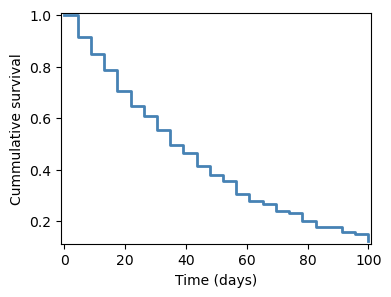

In [2]:
fig, ax = plt.subplots(1, figsize=(4,3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate', ax=ax)
ax.set_ylabel('Cummulative survival')
ax.set_xlabel('Time (days)')

### Adding confidence intervals
Next we will add lines to depict the confidence interval of the survival function. First we will simply match the style of the plotted line, followed by additional customisations. One can also decide to only plot one side of the confidence interval.

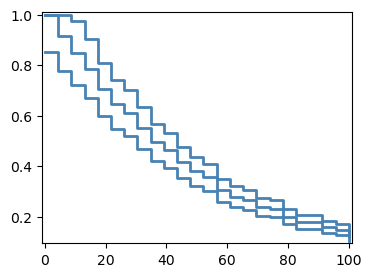

In [3]:
fig, ax = plt.subplots(1, figsize=(4,3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate',
                                 lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                 ax=ax)

Next we will change the linestyle, the width, and the colour of the confidence intervals

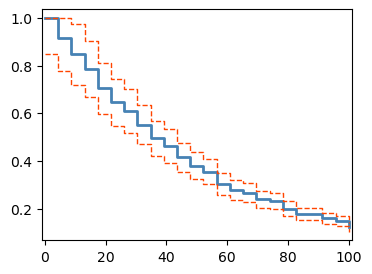

In [4]:
fig, ax = plt.subplots(1, figsize=(4,3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate',
                                 lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                 line_colour_ci='orangered', line_width_ci=1, line_style_ci='--',
                                 ax=ax, margins=(0.01, 0.04),)

Plotting a one-sided confidence interval

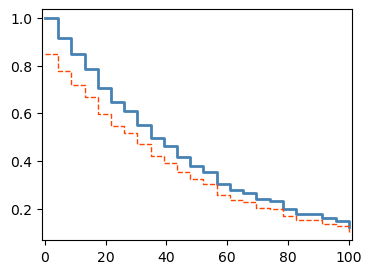

In [5]:
fig, ax = plt.subplots(1, figsize=(4,3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate',
                                 lower_ci_col='lower_ci_95', 
                                 line_colour_ci='orangered', line_width_ci=1, line_style_ci='--',
                                 ax=ax, margins=(0.01, 0.04),)

### Adding a fill between the limits

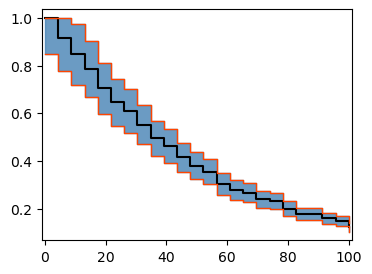

In [6]:
fig, ax = plt.subplots(1, figsize=(4,3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate',
                                 lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                 line_colour='black', line_width=1.5,
                                 line_colour_ci='orangered', line_width_ci=1,
                                 fill=True,  fill_colour='steelblue',                              
                                 ax=ax, margins=(0.01, 0.04),)

To remove the line around the fill we simply set the `line_width_ci` to zero. 

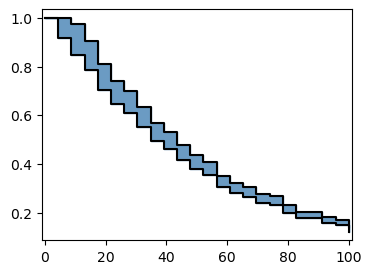

In [7]:
fig, ax = plt.subplots(1, figsize=(4,3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate',
                                 upper_ci_col='upper_ci_95',
                                 line_colour='black', line_width=1.5, line_width_ci=1.5, 
                                 fill=True,  fill_colour='steelblue',                              
                                 ax=ax, margins=(0.01, 0.04),)

We can also add a fill for a one-sided confidence interval. 

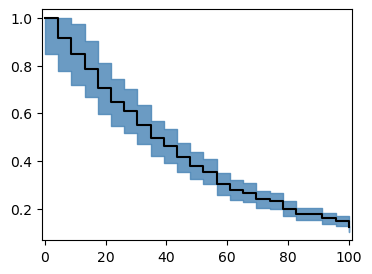

In [8]:
fig, ax = plt.subplots(1, figsize=(4,3))
_, ax = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate',
                                 lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                 line_colour='black', line_width=1.5, line_width_ci=0, 
                                 fill=True,  fill_colour='steelblue',                              
                                 ax=ax, margins=(0.01, 0.04),)

## Plotting the survival function for multiple groups

To plot the survival function for multiple groups we simply add multiple lines using the `add` parameter ensuring the `axes` formatting does not change between lines. Note we will also truncate the follow-up time to focus on first 80 days.

Text(0.5, 0, 'Time (days)')

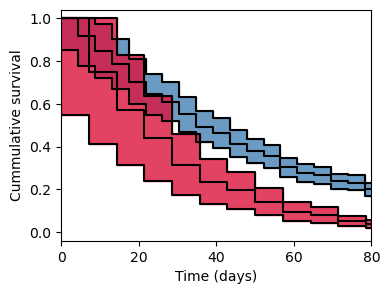

In [9]:
surv_table2 = examples.create_survival_data(nrows=15, survival_rate=0.04, ci_width=0.45)
fig, ax = plt.subplots(1, figsize=(4,3))
_, _ = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate', line_width=1.5, line_colour='black',
                                lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                line_width_ci=1.5, fill_colour='steelblue',   fill=True,
                                ax=ax, xlim=(0, 80), margins=(0.01, 0.04),)
_, _ = pltm_surv.plot_step_wise(surv_table2, estimate_col='survival_estimate', line_colour='black', line_width=1.5, 
                                lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                line_width_ci=1.5, fill_colour='crimson',   fill=True,
                                ax=ax, add=True)
ax.set_ylabel('Cummulative survival')
ax.set_xlabel('Time (days)')


# Survival plot with table

The **risk table** (or at-risk table) appears beneath survival plot, showing the number of subjects remaining under observation at each time point. This table can be expanded by adding multiple rows per line or by adding the cummulative number of subjects with an event and/or the number of subjects who were censored. Below we will use the functions `extract_follow_up_data` and `plot_table` to create and plot this table.   

In [10]:
# preparing the table
bottom_table1 = pltm_surv.extract_follow_up(surv_table, at_risk_col='at_risk', points=[0, 50, 100],)
bottom_table2 = pltm_surv.extract_follow_up(surv_table2, at_risk_col='at_risk', points=[0, 50, 100],)

# merge tables
sel_col =['time','group_1_at_risk_format']
col_names = ['time', 'group 1', 'group 2']
bottom_table = pd.merge(bottom_table1[sel_col], bottom_table2[sel_col], on=['time'])
bottom_table.columns = col_names
bottom_table


,time,group 1,group 2
0,0,"1,000","1,000"
1,50,379,143
2,100,121,1


Text(0.5, 0, 'Time (days)')

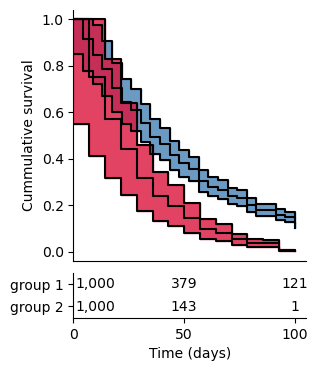

In [14]:
f, axs = plt.subplots(nrows=2, ncols=1, figsize=(3, 4),
                     gridspec_kw={'height_ratios': [10,1.8]},
                     sharex=False,
                     )
plt.subplots_adjust(hspace=0.08)

# the survival curve
_, _ = pltm_surv.plot_step_wise(surv_table, estimate_col='survival_estimate', line_width=1.5, line_colour='black',
                                lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                line_width_ci=1.5, fill_colour='steelblue',   fill=True,
                                ax=axs[0], xlim=(0, 80), margins=(0.01, 0.04),)
_, _ = pltm_surv.plot_step_wise(surv_table2, estimate_col='survival_estimate', line_colour='black', line_width=1.5, 
                                lower_ci_col='lower_ci_95', upper_ci_col='upper_ci_95',
                                line_width_ci=1.5, fill_colour='crimson', fill=True,
                                ax=axs[0], add=True)




# adding the table
xlims=(0,105)
axs[0].set_xlim(xlims)
axs[1].set_xlim(xlims)

_ = pltm_surv.plot_table(bottom_table, ax=axs[1], string_col=col_names[1:], 
                         yticklabel=col_names[1:],
                         size_text=10,
                         yloc=[0.25, 0.75],
                         xticklabel=bottom_table[col_names[0]].to_list(),
                         xtickloc=bottom_table[col_names[0]].to_list(),
                         pad_first = 11,
                                            
)


# formatting
axs[0].spines[['top', 'right']].set_visible(False)
axs[0].set_ylabel('Cummulative survival')
axs[0].set_xticks([])
axs[1].set_xlabel('Time (days)')